# Walmart Weekly Sales Prediction

### Imports & Data Loading

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [62]:
df = pd.read_csv("C:/Users/mickt/Downloads/Walmart_Store_sales(1).csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


# Part 1 — Exploratory Data Analysis & Preprocessing

#### The dataset contains weekly Walmart sales across multiple stores, along with store
#### information, calendar indicators, and economic variables.

#### Target variable:
#### - Weekly_Sales

### Dataset Overview

In [63]:
df.shape

(150, 8)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


In [65]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


#### Initial inspection shows:
#### - Missing values in both predictors and target
#### - Mixed variable types (categorical, numerical, temporal)
#### - Strong variation in weekly sales across stores

### Missing Target Values

#### Rows with missing values in Weekly_Sales are removed.

#### This is necessary because:
#### - Weekly_Sales is the target variable
#### - imputing target values would introduce bias into the model

In [66]:
df = df[df["Weekly_Sales"].notnull()].copy()
df.shape

(136, 8)

### Date Preprocessing

#### The Date column cannot be used directly in a regression model,
#### so it is transformed into numeric calendar features:
#### - Year
#### - Month
#### - Day
#### - DayOfWeek

In [67]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")

In [68]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [69]:
start_date = df["Date"].min()
end_date = df["Date"].max()
print(start_date, end_date)

2010-02-05 00:00:00 2012-10-19 00:00:00


#### The dataset spans from 2010-02-05 to 2012-10-19

In [70]:
df.drop(columns=["Date"], inplace=True)

### Outlier Removal

#### Outliers are removed from:
#### - Temperature
#### - Fuel_Price
#### - CPI
#### - Unemployment

#### An observation is considered an outlier if it falls outside:
#### [μ - 3σ, μ + 3σ]

In [71]:
numerical_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

In [72]:
for col in numerical_cols:
    col_mean = df[col].mean()
    col_std = df[col].std()

    lower = col_mean - 3 * col_std
    upper = col_mean + 3 * col_std

    df = df[(df[col].isna()) | ((df[col] >= lower) & (df[col] <= upper))]

### Exploratory Visualizations

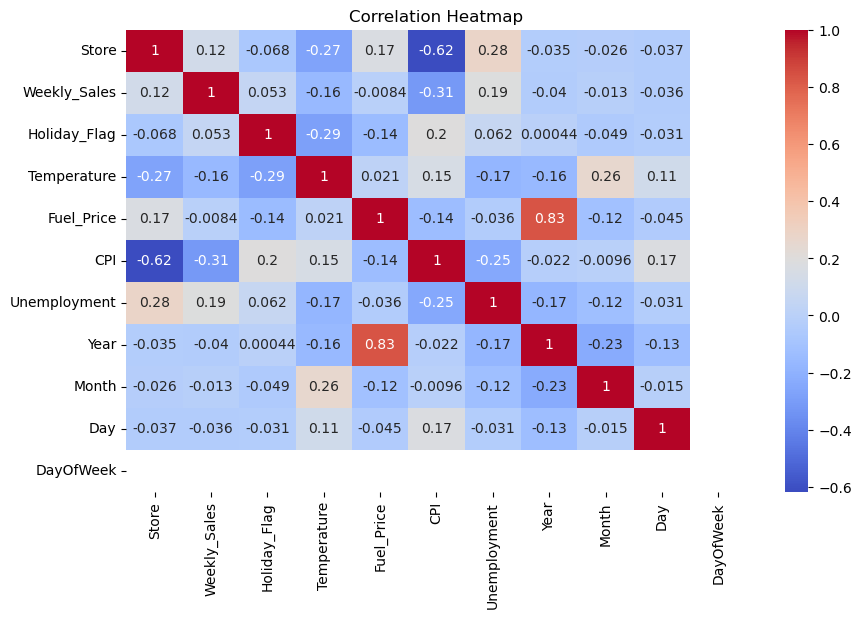

In [73]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

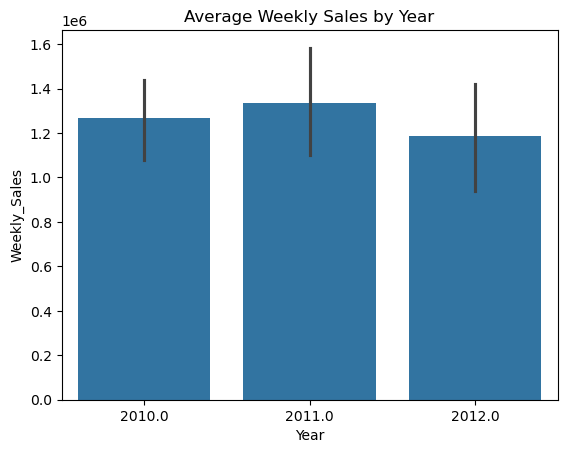

In [74]:
sns.barplot(data=df, x="Year", y="Weekly_Sales")
plt.title("Average Weekly Sales by Year")
plt.show()

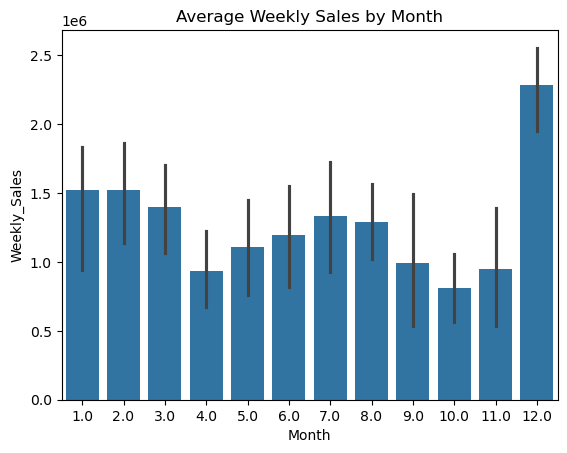

In [75]:
sns.barplot(data=df, x="Month", y="Weekly_Sales")
plt.title("Average Weekly Sales by Month")
plt.show()

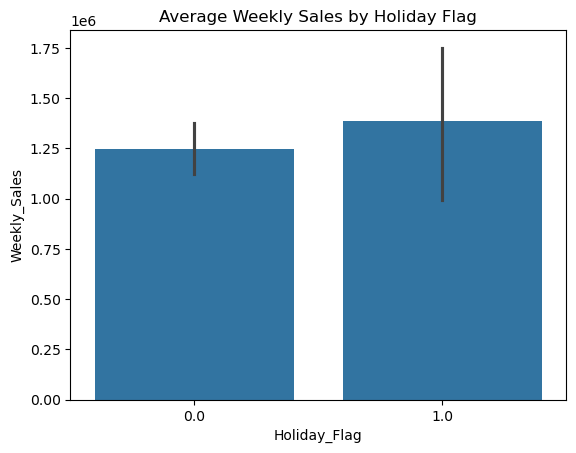

In [76]:
sns.barplot(data=df, x="Holiday_Flag", y="Weekly_Sales")
plt.title("Average Weekly Sales by Holiday Flag")
plt.show()

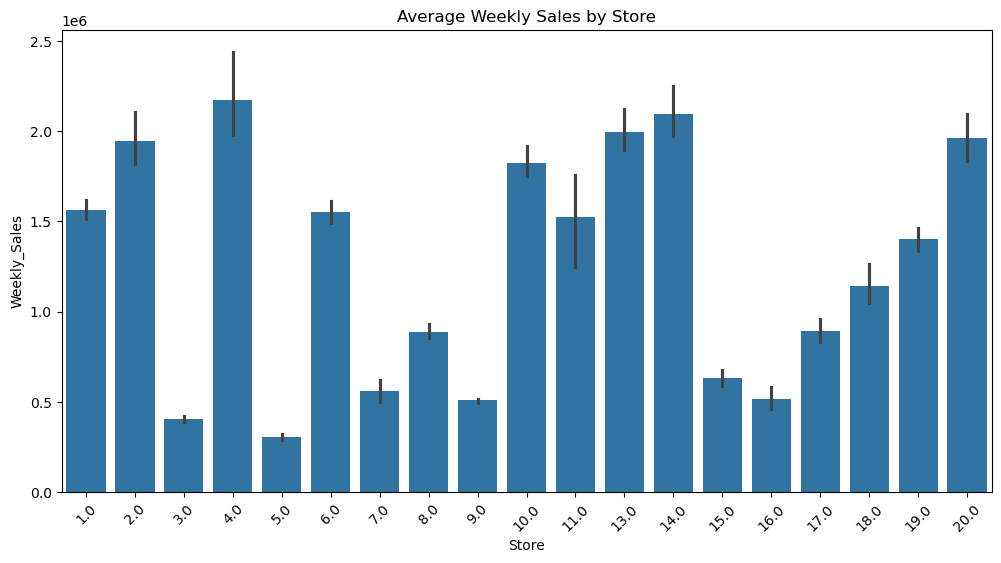

In [77]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Store", y="Weekly_Sales")
plt.title("Average Weekly Sales by Store")
plt.xticks(rotation=45)
plt.show()

#### Main findings:
#### - Sales vary strongly across stores
#### - Holiday weeks show slightly higher sales variability
#### - Seasonality is moderate
#### - Store identity appears to be the strongest driver of sales

# # Part 2 — Baseline Model (Linear Regression)

In [78]:
categorical_features = ["Store", "Holiday_Flag"]
numerical_features = [
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "Year", "Month", "Day", "DayOfWeek"
]

### Preprocessing Pipeline

In [79]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

In [80]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

In [81]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

### Train/Test Split

In [82]:
X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression

In [84]:
linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [85]:
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

In [86]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.8908899782259927
MAE: 153207.87386465404
RMSE: 194681.863981579


#### The baseline model explains approximately 89% of the variance
#### in weekly sales, indicating strong predictive performance.

## Part 3 — Regularization

#### To assess overfitting, two regularized regression models are tested:
#### - Ridge Regression (L2)
#### - Lasso Regression (L1)

### Ridge Regression

In [87]:
ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", Ridge(alpha=0.001115))
])


In [88]:
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

In [89]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.8910327242036761
MAE: 153061.77644927579
RMSE: 194554.473537641


#### Ridge regression produces nearly identical results to the baseline model,suggesting limited overfitting.

### Lasso Regression

#### Because Lasso is sensitive to feature scale, numerical features are standardized.

In [90]:
num_pipeline_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [91]:
preprocessor_lasso = ColumnTransformer([
    ("num", num_pipeline_lasso, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [92]:
lasso_model = Pipeline([
    ("preprocessing", preprocessor_lasso),
    ("regressor", Lasso(alpha=0.2, max_iter=10000))
])

In [93]:
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)

In [94]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.8908927821781206
MAE: 153205.81858609166
RMSE: 194679.3624600643


#### Lasso achieves performance nearly identical to the baseline model while shrinking weak coefficients.

### Hyperparameter Tuning

In [95]:
param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

In [96]:
grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

In [97]:
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_["regressor__alpha"])

Best alpha: 100


#### A strong regularization parameter is selected, indicating that only a subset of features contributes strongly to prediction.

### Feature Importance

#### Feature importance is assessed using model coefficients.

In [98]:
regressor = ridge_model.named_steps["regressor"]
coefficients = regressor.coef_

In [99]:
preprocessor_fitted = ridge_model.named_steps["preprocessing"]

In [100]:
num_features = numerical_features
cat_features = preprocessor_fitted.named_transformers_["cat"] \
    .named_steps["encoder"].get_feature_names_out(categorical_features)

In [101]:
all_features = list(num_features) + list(cat_features)

In [102]:
coef_df = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

In [103]:
coef_df.head(15)

,Feature,Coefficient
11,Store_5.0,-1.358328e+06
9,Store_3.0,-1.200887e+06
21,Store_16.0,-1.174743e+06
15,Store_9.0,-1.140858e+06
13,Store_7.0,-9.930518e+05
20,Store_15.0,-8.625203e+05
22,Store_17.0,-8.552050e+05
14,Store_8.0,-7.952942e+05
19,Store_14.0,5.809760e+05
10,Store_4.0,4.903830e+05


### Feature Importance Visualization

In [104]:
feature_importance = coef_df.set_index("Feature")["Coefficient"]

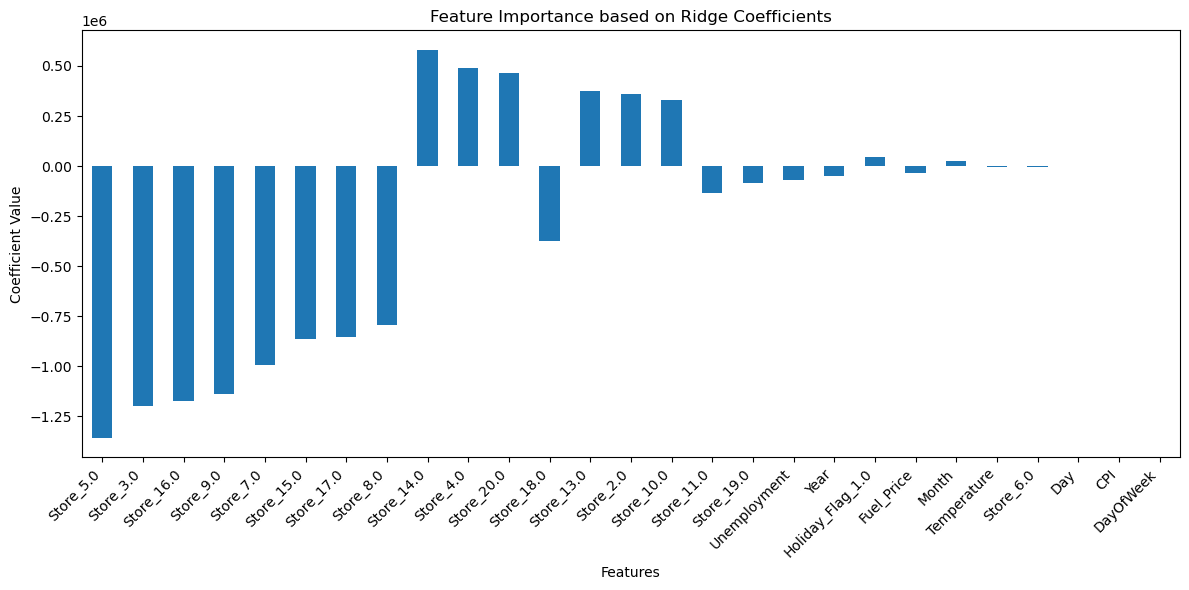

In [105]:
plt.figure(figsize=(12, 6))
feature_importance.plot(kind="bar")
plt.title("Feature Importance based on Ridge Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Main findings:
#### - Store identity is by far the strongest predictor
#### - Unemployment and CPI have moderate influence
#### - Fuel_Price has weak influence
#### - DayOfWeek has no measurable effect

# Final Conclusion

#### This project demonstrates that weekly Walmart sales can be predicted accurately using a linear modeling approach.
#### The baseline linear regression model explains approximately 89% of the variance in weekly sales, indicating strong predictive performance.
#### Among all predictors, store identity is by far the strongest driver of weekly sales, suggesting that structural store-level differences dominate the signal in the dataset.

#### Regularization did not improve predictive performance:
#### - Ridge confirmed limited overfitting
#### - Lasso confirmed that several predictors contribute little and can be shrunk toward zero

#### Overall, weekly Walmart sales are driven far more by store-specific effects than by short-term economic indicators.